<a href="https://colab.research.google.com/github/Andreyana1001/smart-finance-assistant/blob/main/Copy_of_smart_finance_assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Finance Assistant: Savings Coach

## 1. Understand the Problem

Many people want to save money but struggle to stay motivated, plan realistic goals, and understand how much they need to save each month. This project solves that problem by creating a Savings Coach that gives encouragement, explains simple saving strategies, and calculates how much money the user needs to save regularly to reach a financial goal.

The assistant is designed for users who have a savings target, such as buying a laptop, paying for travel, building an emergency fund, or saving for university expenses. It combines a friendly finance chatbot, a savings goal calculator tool, retrieval from savings advice notes, and a simple Gradio interface.

## 2. Identify Inputs and Outputs

### Inputs
- User’s savings goal amount
- User’s current savings amount
- Number of months available to save
- User questions about saving money
- Savings advice notes for retrieval

### Outputs
- Remaining amount needed
- Monthly savings required
- Weekly savings required
- Encouraging savings advice
- Chatbot responses based on finance coaching

## 3. Work the Problem by Hand

### Example 1

Savings Goal: $5,000  
Current Savings: $1,000  
Time Frame: 8 months

Step 1: Calculate remaining amount

$5,000 - $1,000 = $4,000

Step 2: Calculate monthly savings needed

$4,000 ÷ 8 = $500 per month

Step 3: Calculate weekly savings needed

$500 ÷ 4 = $125 per week

Result:
The user needs to save approximately $500 per month or $125 per week to reach the goal.

---

### Example 2

Savings Goal: $12,000  
Current Savings: $2,000  
Time Frame: 10 months

Step 1: Remaining amount

$12,000 - $2,000 = $10,000

Step 2: Monthly savings needed

$10,000 ÷ 10 = $1,000 per month

Step 3: Weekly savings needed

$1,000 ÷ 4 = $250 per week

Result:
The user needs to save approximately $1,000 per month or $250 per week.

## 4. Write Pseudocode

1. Ask the user for:
   - savings goal
   - current savings
   - number of months

2. Calculate remaining savings needed

3. Calculate monthly savings amount

4. Calculate weekly savings amount

5. Display savings summary

6. Generate encouraging financial advice

7. Allow the user to interact with the chatbot

8. Display everything using a Gradio interface


In [ ]:
# Step 5: Convert to Python
# Install required libraries

!pip install gradio -q

In [ ]:
# Import required libraries

import gradio as gr

In [ ]:
def calculate_savings_goal(goal_amount, current_savings, months):
    """
    Calculates how much the user needs to save monthly and weekly
    to reach their savings goal.
    """

    if goal_amount <= 0:
        return "Error: The savings goal must be greater than 0."

    if current_savings < 0:
        return "Error: Current savings cannot be negative."

    if months <= 0:
        return "Error: Number of months must be greater than 0."

    remaining_amount = goal_amount - current_savings

    if remaining_amount <= 0:
        return "Congratulations! You have already reached your savings goal."

    monthly_savings = remaining_amount / months
    weekly_savings = monthly_savings / 4

    result = f"""
Savings Goal Summary

Goal Amount: ${goal_amount:.2f}
Current Savings: ${current_savings:.2f}
Remaining Amount: ${remaining_amount:.2f}

You need to save:
- ${monthly_savings:.2f} per month
- ${weekly_savings:.2f} per week

Encouragement:
You can do this! Try setting aside this amount as soon as you receive your income.
"""

    return result

In [ ]:
print(calculate_savings_goal(5000, 1000, 8))


Savings Goal Summary

Goal Amount: $5000.00
Current Savings: $1000.00
Remaining Amount: $4000.00

You need to save:
- $500.00 per month
- $125.00 per week

Encouragement:
You can do this! Try setting aside this amount as soon as you receive your income.



In [ ]:
def savings_coach_chat(user_message):
    """
    A simple finance chatbot that gives savings encouragement and advice.
    """

    user_message = user_message.lower()

    if "save" in user_message:
        return "Saving money consistently, even in small amounts, can build strong financial habits."

    elif "budget" in user_message:
        return "A good budgeting strategy is the 50/30/20 rule: 50% needs, 30% wants, and 20% savings."

    elif "motivate" in user_message or "motivation" in user_message:
        return "Every small saving today brings you closer to your financial goals tomorrow."

    elif "emergency fund" in user_message:
        return "Experts often recommend saving at least 3 to 6 months of living expenses for emergencies."

    elif "help" in user_message:
        return "I can help you calculate savings goals and give budgeting encouragement."

    else:
        return "That’s a great financial question. Building saving habits takes patience and consistency."

In [ ]:
print(savings_coach_chat("How can I save money?"))

Saving money consistently, even in small amounts, can build strong financial habits.


In [ ]:
print(savings_coach_chat("Give me motivation"))
print(savings_coach_chat("Tell me about budgeting"))
print(savings_coach_chat("What is an emergency fund?"))

Every small saving today brings you closer to your financial goals tomorrow.
A good budgeting strategy is the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.
Experts often recommend saving at least 3 to 6 months of living expenses for emergencies.


In [ ]:
import gradio as gr
import matplotlib.pyplot as plt


# Savings Calculator Function
def calculate_savings_goal(goal_amount, current_savings, months):

    if goal_amount <= 0:
        return "Error: Goal amount must be greater than 0."

    if current_savings < 0:
        return "Error: Current savings cannot be negative."

    if months <= 0:
        return "Error: Months must be greater than 0."

    remaining_amount = goal_amount - current_savings

    if remaining_amount <= 0:
        return "Congratulations! You have already reached your savings goal."

    monthly_savings = remaining_amount / months
    weekly_savings = monthly_savings / 4

    return f"""
Savings Goal Summary

Goal Amount: ${goal_amount:.2f}
Current Savings: ${current_savings:.2f}
Remaining Amount: ${remaining_amount:.2f}

You need to save:
- ${monthly_savings:.2f} per month
- ${weekly_savings:.2f} per week

Savings Coach Advice:
Stay consistent and track your progress regularly.
"""


# RAG Notes
savings_advice_notes = [
    "Set a clear savings goal so you know exactly what you are working toward.",
    "Pay yourself first by saving money as soon as you receive income.",
    "Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.",
    "Build an emergency fund with 3 to 6 months of essential expenses.",
    "Track small daily spending because small expenses can add up quickly.",
    "Use automatic transfers to move money into savings regularly.",
    "Reduce unnecessary subscriptions and impulse purchases.",
    "Review your savings progress weekly to stay motivated."
]


# Retrieve Advice
def retrieve_savings_advice(user_question):

    user_question = user_question.lower()
    matching_notes = []

    for note in savings_advice_notes:
        if any(word in note.lower() for word in user_question.split()):
            matching_notes.append(note)

    if matching_notes:
        return "\n".join(matching_notes[:3])

    return "Set a realistic savings goal and save consistently."


# Chatbot with RAG
def savings_coach_chat_with_rag(user_message):

    advice = retrieve_savings_advice(user_message)

    response = f"""
Savings Coach Response

{advice}

Encouragement:
Small savings today can create financial security tomorrow.
"""

    return response


# Savings Chart
def generate_savings_chart(goal_amount, current_savings, months):

    remaining_amount = goal_amount - current_savings
    monthly_savings = remaining_amount / months

    months_list = list(range(1, int(months) + 1))
    savings_progress = []

    total = current_savings

    for month in months_list:
        total += monthly_savings
        savings_progress.append(total)

    plt.figure(figsize=(8, 5))
    plt.plot(months_list, savings_progress, marker='o')

    plt.xlabel("Months")
    plt.ylabel("Total Savings")
    plt.title("Savings Goal Progress")

    plt.grid(True)

    return plt.gcf()


# Gradio UI
with gr.Blocks() as demo:

    gr.Markdown("# Smart Finance Assistant: Savings Coach")

    with gr.Tab("Savings Calculator"):

        goal_amount = gr.Number(label="Savings Goal Amount")
        current_savings = gr.Number(label="Current Savings")
        months = gr.Number(label="Number of Months")

        calculate_button = gr.Button("Calculate Savings Plan")

        savings_output = gr.Textbox(label="Savings Plan")

        calculate_button.click(
            fn=calculate_savings_goal,
            inputs=[goal_amount, current_savings, months],
            outputs=savings_output
        )

    with gr.Tab("Savings Chart"):

        chart_goal = gr.Number(label="Savings Goal Amount")
        chart_current = gr.Number(label="Current Savings")
        chart_months = gr.Number(label="Number of Months")

        chart_button = gr.Button("Generate Chart")

        chart_output = gr.Plot(label="Savings Progress Chart")

        chart_button.click(
            fn=generate_savings_chart,
            inputs=[chart_goal, chart_current, chart_months],
            outputs=chart_output
        )

    with gr.Tab("Savings Coach Chatbot"):

        chatbot_input = gr.Textbox(label="Ask the Savings Coach")
        chatbot_output = gr.Textbox(label="Coach Response")

        chatbot_button = gr.Button("Send")

        chatbot_button.click(
            fn=savings_coach_chat_with_rag,
            inputs=chatbot_input,
            outputs=chatbot_output
        )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffbc2229cf8ac20509.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## RAG: Savings Advice Notes

The Savings Coach uses a small knowledge base of savings advice. This helps the assistant give more relevant responses instead of only using general chatbot replies.

In [ ]:
savings_advice_notes = [
    "Set a clear savings goal so you know exactly what you are working toward.",
    "Pay yourself first by saving money as soon as you receive income.",
    "Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.",
    "Build an emergency fund with 3 to 6 months of essential expenses.",
    "Track small daily spending because small expenses can add up quickly.",
    "Use automatic transfers to move money into savings regularly.",
    "Reduce unnecessary subscriptions and impulse purchases.",
    "Review your savings progress weekly to stay motivated."
]

In [ ]:
def retrieve_savings_advice(user_question):
    user_question = user_question.lower()
    matching_notes = []

    for note in savings_advice_notes:
        if any(word in note.lower() for word in user_question.split()):
            matching_notes.append(note)

    if matching_notes:
        return "\n".join(matching_notes[:3])
    else:
        return "Set a realistic savings goal, track your spending, and save consistently every week."

In [ ]:
print(retrieve_savings_advice("How can I stop impulse spending?"))

Set a clear savings goal so you know exactly what you are working toward.
Pay yourself first by saving money as soon as you receive income.
Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.


In [ ]:
savings_advice_notes = [
    "Set a clear savings goal so you know exactly what you are working toward.",
    "Pay yourself first by saving money as soon as you receive income.",
    "Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.",
    "Build an emergency fund with 3 to 6 months of essential expenses.",
    "Track small daily spending because small expenses can add up quickly.",
    "Use automatic transfers to move money into savings regularly.",
    "Reduce unnecessary subscriptions and impulse purchases.",
    "Review your savings progress weekly to stay motivated."
]

In [ ]:
def retrieve_savings_advice(user_question):
    user_question = user_question.lower()
    matching_notes = []

    for note in savings_advice_notes:
        if any(word in note.lower() for word in user_question.split()):
            matching_notes.append(note)

    if matching_notes:
        return "\n".join(matching_notes[:3])
    else:
        return "Set a realistic savings goal, track your spending, and save consistently every week."

In [ ]:
print(retrieve_savings_advice("How can I stop impulse spending?"))

Set a clear savings goal so you know exactly what you are working toward.
Pay yourself first by saving money as soon as you receive income.
Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.


In [ ]:
def savings_coach_chat_with_rag(user_message):
    """
    Savings Coach chatbot that uses retrieved savings advice notes.
    """

    advice = retrieve_savings_advice(user_message)

    response = f"""
Savings Coach Response:

{advice}

Encouragement:
You are making progress by thinking about your money. Small consistent actions can lead to big results over time.
"""

    return response

In [ ]:
print(savings_coach_chat_with_rag("How can I reduce impulse purchases?"))


Savings Coach Response:

Set a clear savings goal so you know exactly what you are working toward.
Pay yourself first by saving money as soon as you receive income.
Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.

Encouragement:
You are making progress by thinking about your money. Small consistent actions can lead to big results over time.



## 6. Testing with a Variety of Data

The following tests were used to verify that the Savings Coach Assistant works correctly under normal, edge, and error conditions.

In [ ]:
# Normal Test Case
print(calculate_savings_goal(5000, 1000, 8))

# Edge Case: Goal already reached
print(calculate_savings_goal(5000, 6000, 8))

# Error Case: Negative savings
print(calculate_savings_goal(5000, -100, 8))

# Error Case: Invalid months
print(calculate_savings_goal(5000, 1000, 0))

# RAG Test
print(retrieve_savings_advice("How do I build an emergency fund?"))

# Chatbot Test
print(savings_coach_chat_with_rag("How can I save money consistently?"))


Savings Goal Summary

Goal Amount: $5000.00
Current Savings: $1000.00
Remaining Amount: $4000.00

You need to save:
- $500.00 per month
- $125.00 per week

Savings Coach Advice:
Stay consistent and track your progress regularly.

Congratulations! You have already reached your savings goal.
Error: Current savings cannot be negative.
Error: Months must be greater than 0.
Set a clear savings goal so you know exactly what you are working toward.
Pay yourself first by saving money as soon as you receive income.
Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.

Savings Coach Response:

Set a clear savings goal so you know exactly what you are working toward.
Pay yourself first by saving money as soon as you receive income.
Use the 50/30/20 rule: 50% needs, 30% wants, and 20% savings.

Encouragement:
You are making progress by thinking about your money. Small consistent actions can lead to big results over time.



In [ ]:
# Assertions

assert "Congratulations" in calculate_savings_goal(5000, 6000, 8)

assert "Error" in calculate_savings_goal(5000, -100, 8)

assert "Error" in calculate_savings_goal(5000, 1000, 0)

print("All tests passed successfully.")

All tests passed successfully.


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def generate_savings_chart(goal_amount, current_savings, months):

    remaining_amount = goal_amount - current_savings
    monthly_savings = remaining_amount / months

    months_list = list(range(1, int(months) + 1))
    savings_progress = []

    total = current_savings

    for month in months_list:
        total += monthly_savings
        savings_progress.append(total)

    plt.figure(figsize=(8, 5))
    plt.plot(months_list, savings_progress, marker='o')

    plt.xlabel("Months")
    plt.ylabel("Total Savings")
    plt.title("Savings Goal Progress")

    plt.grid(True)

    plt.show()

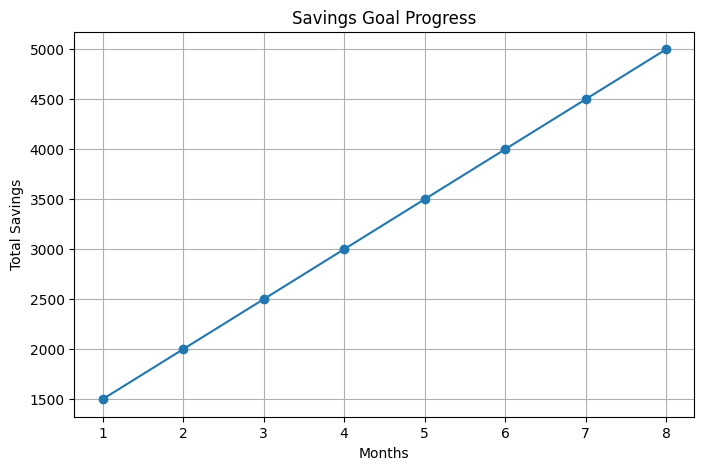

In [ ]:
generate_savings_chart(5000, 1000, 8)